In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Importing the dataset
dataset = pd.read_csv("weatherHistory.csv")

# Selecting Features (Temperature and Humidity)
X = dataset[['Temperature (C)', 'Humidity']].values

# Target Variable (Weather Summary)
y = dataset['Summary'].values

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Training the Naive Bayes model on the Training set
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

print("Predicted Test Results :")
print(y_pred)
print("~" * 20)

# Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score

ac = accuracy_score(y_test, y_pred)
print("Model Accuracy :", ac * 100, "%")
print("~" * 20)

cm = confusion_matrix(y_test, y_pred)
print("Model Confusion Matrix :")
print(cm)

Predicted Test Results :
['Partly Cloudy' 'Mostly Cloudy' 'Partly Cloudy' ... 'Partly Cloudy'
 'Partly Cloudy' 'Mostly Cloudy']
~~~~~~~~~~~~~~~~~~~~
Model Accuracy : 38.91999277587141 %
~~~~~~~~~~~~~~~~~~~~
Model Confusion Matrix :
[[   0    0    0    0    0    0    0    0    0    0    0    0    0    2
     2    3    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    8    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0   25
     9   33    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0   10
    40   10    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0   16
     3   28    0    0    0    0]
 [   0    0    0    0    0    1    0    0    0  203    0    0    0  364
   387  510    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    1    0    0    0    0]
 [   0    0    0    0    0    0  

Libraries imported


Saving weatherHistory.csv to weatherHistory (1).csv
Dataset Loaded
Transformed Data
[[-0.25759902 -0.32403547  0.79347043  0.47863499  0.10168518]
 [-0.26981351 -0.3390971   0.63999555  0.49959388  0.1059598 ]
 [-0.26748694 -0.13810226  0.79347043 -0.99547337  0.10861007]
 ...
 [ 1.0580761   1.04553403 -0.89475327 -0.2642411   0.10621628]
 [ 1.00398335  0.99723295 -0.6901201  -0.04067964  0.10869557]
 [ 0.89056308  0.89595648 -0.6389618  -0.71369278  0.11049091]]
GaussianNB()

Predicted Values:
['Mostly Cloudy' 'Partly Cloudy' 'Partly Cloudy' ... 'Partly Cloudy'
 'Partly Cloudy' 'Mostly Cloudy']

Model Accuracy : 38.94802322366602 %

Confusion Matrix:
[[   6    0    3    5    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    2    0    0    0    0]
 [   0   14    0    1    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   1    0   53   61   24    0    0    0    0    3    0    0    0    0
     0    9    0  

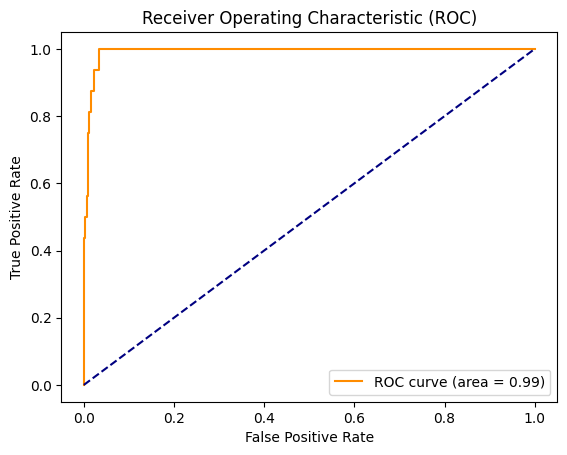

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

print("Libraries imported")

from google.colab import files

# Upload the CSV file
uploaded = files.upload()
weather_df = pd.read_csv("weatherHistory.csv")
print("Dataset Loaded")

# Predictor variables (Numerical Features)
X = weather_df[['Temperature (C)',
                'Apparent Temperature (C)',
                'Humidity',
                'Wind Speed (km/h)',
                'Pressure (millibars)']]

# Target variable
y = weather_df["Summary"]

# Feature Scaling
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X = std.fit_transform(X)

print("Transformed Data")
print(X)

# Split the data into Training and Test sets
test_size = 0.30      # 70% Training, 30% Testing
seed = 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=seed
)

# Create Gaussian Naive Bayes Model
model = GaussianNB()

# Train the Model
model.fit(X_train, y_train)
print(model)

# Predict Test Data
predicted = model.predict(X_test)

print("\nPredicted Values:")
print(predicted)

# Accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, predicted)
print("\nModel Accuracy :", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, predicted)

print("\nConfusion Matrix:")
print(cm)

# Model Score
model_score = model.score(X_test, y_test)
print("\nModel Score :", model_score)

# Prediction Probabilities
y_predictProb = model.predict_proba(X_test)

print("\nPrediction Probabilities:")
print(y_predictProb)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=test_size,
    random_state=seed
)

model.fit(X_train, y_train)

y_predictProb = model.predict_proba(X_test)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Using first class vs rest
fpr, tpr, thresholds = roc_curve(y_test == 0, y_predictProb[:, 0])
roc_auc = auc(fpr, tpr)

print("\nROC AUC :", roc_auc)

# Plot ROC Curve
plt.plot(fpr, tpr, color='darkorange',
         label='ROC curve (area = %0.2f)' % roc_auc)

plt.plot([0, 1], [0, 1],
         color='navy',
         linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()